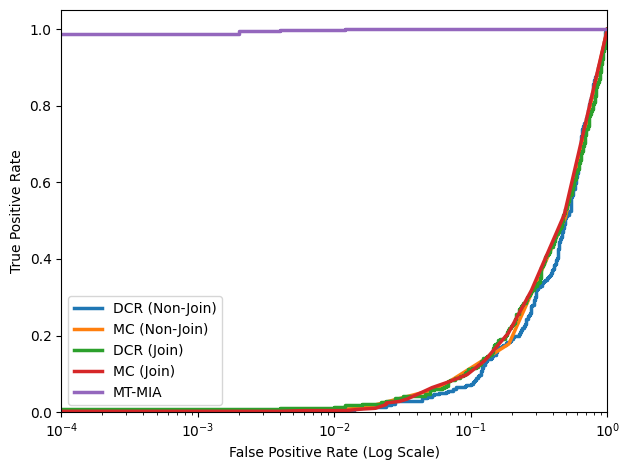

In [10]:
import pandas as pd
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
from src.synth_mia.attackers import dcr, mc
from src.synth_mia.utils import tabular_preprocess
import numpy as np
import pandas as pd

mem_t1 = pd.read_csv('../data/toy/mem/t1.csv')
non_mem_t1 = pd.read_csv('../data/toy/non_mem/t1.csv')
ref_t1 = pd.read_csv('../data/toy/ref/t1.csv')
synth_t1 = pd.read_csv('../data/toy/synth/t1.csv')

mem_t2 = pd.read_csv('../data/toy/mem/t2.csv')
non_mem_t2 = pd.read_csv('../data/toy/non_mem/t2.csv')
ref_t2 = pd.read_csv('../data/toy/ref/t2.csv')
synth_t2 = pd.read_csv('../data/toy/synth/t2.csv')

# Keep only the first row from t2 for each t1_id
mem_t2_unique = mem_t2.drop_duplicates(subset='t1_id', keep='first')
non_mem_t2_unique = non_mem_t2.drop_duplicates(subset='t1_id', keep='first')
ref_t2_unique = ref_t2.drop_duplicates(subset='t1_id', keep='first')
synth_t2_unique = synth_t2.drop_duplicates(subset='t1_id', keep='first')

# Join t1 with t2 on t1_id for each dataset type (now guaranteed 1-to-1)
mem_joined = mem_t1.merge(mem_t2_unique, on='t1_id', how='left')
non_mem_joined = non_mem_t1.merge(non_mem_t2_unique, on='t1_id', how='left')
ref_joined = ref_t1.merge(ref_t2_unique, on='t1_id', how='left')
synth_joined = synth_t1.merge(synth_t2_unique, on='t1_id', how='left')

# Drop t1_id and t2_id columns
mem_final = mem_joined.drop(columns=['t1_id', 't2_id'], errors='ignore').values
non_mem_final = non_mem_joined.drop(columns=['t1_id', 't2_id'], errors='ignore').values
ref_final = ref_joined.drop(columns=['t1_id', 't2_id'], errors='ignore').values
synth_final = synth_joined.drop(columns=['t1_id', 't2_id'], errors='ignore').values

# Other attackers remain the same
attackers = [
    dcr(),
    mc(),
]
    
# Run attacks for this specific synthetic dataset
results = {}

for attacker in attackers:
    # Run the attack
    scores, true_labels = attacker.attack(mem_final, 
                                        non_mem_final, 
                                        synth_final,
                                        ref_final
                                        )
    
    # Evaluate the attack
    eval_results = attacker.eval(true_labels, scores, metrics=['roc'])
    
    # Store results
    results[attacker.name] = eval_results
(pd.DataFrame(results).T)

mem_t1 = pd.read_csv('../data/toy/mem/t1.csv').values
non_mem_t1 = pd.read_csv('../data/toy/non_mem/t1.csv').values
ref_t1 = pd.read_csv('../data/toy/ref/t1.csv').values
synth_t1 = pd.read_csv('../data/toy/synth/t1.csv').values

attackers = [
    dcr(),
    mc(),
]
    
# Run attacks for this specific synthetic dataset
results = {}

for attacker in attackers:
    # Run the attack
    scores, true_labels = attacker.attack(mem_t1, 
                                        non_mem_t1, 
                                        synth_t1,
                                        ref_t1
                                        )
    
    # Evaluate the attack
    eval_results = attacker.eval(true_labels, scores, metrics=['roc'])
    
    # Store results
    results[attacker.name] = eval_results

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import json

# -----------------------------
# NON-JOIN (t1 only)
# -----------------------------
nonjoin_scores = {}
nonjoin_labels = None
attackers = [
    dcr(),
    mc(),
]
for attacker in attackers:
    scores, labels = attacker.attack(
        mem_t1,
        non_mem_t1,
        synth_t1,
        ref_t1
    )
    nonjoin_scores[attacker.name] = scores
    nonjoin_labels = labels  # same for all attackers


# -----------------------------
# JOIN (t1 ⨝ t2)
# -----------------------------
join_scores = {}
join_labels = None

for attacker in attackers:
    scores, labels = attacker.attack(
        mem_final,
        non_mem_final,
        synth_final,
        ref_final
    )
    join_scores[attacker.name] = scores
    join_labels = labels
dict_scores = {}

with open("../results_1/toy.json", "r") as f:
    records = [json.loads(line) for line in f if line.strip()]

last_record = records[-1]

# assumes structure: record["full"]["scores"]
dict_scores["dict"] = last_record["full"]["scores"]
dict_labels = join_labels
def plot_roc(scores, labels, label):
    fpr, tpr, _ = roc_curve(labels, scores)
    plt.plot(fpr, tpr, label=label, linewidth=2.5)

# ---- Non-join ----
plot_roc(nonjoin_scores["DCR"], nonjoin_labels, "DCR (Non-Join)")
plot_roc(nonjoin_scores["MC"],  nonjoin_labels, "MC (Non-Join)")

# ---- Join ----
plot_roc(join_scores["DCR"], join_labels, "DCR (Join)")
plot_roc(join_scores["MC"],  join_labels, "MC (Join)")

# ---- Dictionary ----
plot_roc(dict_scores["dict"], dict_labels, "MT-MIA")

# Log scale for FPR
plt.xscale('log')

# Set limits to avoid log(0) issues and show the relevant range
plt.xlim(1e-4, 1.0) 
plt.ylim(0, 1.05)

plt.xlabel("False Positive Rate (Log Scale)")
plt.ylabel("True Positive Rate")

# Removed plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

